<a href="https://colab.research.google.com/github/rajatgusain17/MORGAN-STANLEY-Financial-Risk-Analysis-with-Python/blob/main/Morgan_Stanley_Financial_Risk_Analysis_Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MORGAN STANLEY Financial Risk Analysis **

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as stats
from scipy import stats

In [ ]:
# Loading data
df = pd.read_csv('morgan_stanely.csv')

In [ ]:
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
df.head()

Shape: (800, 15)

Column types:
 TransactionID          int64
CustomerID            object
AccountID             object
AccountType           object
TransactionType       object
Product               object
Firm                  object
Region                object
Manager               object
TransactionDate       object
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

Missing values:
 TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,06-01-2023,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,17-02-2023,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,13-09-2023,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,28-05-2024,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,12-05-2023,77104.456470,57425.69930,1.042441,393,10


In [ ]:
# --- Checking for missing values ---
print("Missing values per column:")
print(df.isna().sum())
print("\nTotal missing cells:", df.isna().sum().sum())

Missing values per column:
TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

Total missing cells: 0


In [ ]:
# --- Checking for duplicate rows ---
print("\n Duplicate rows:", df.duplicated().sum())


 Duplicate rows: 0


In [ ]:
# --- Dropping missing values ---
df = df.dropna()

In [ ]:
# --- Dropping fully duplicate rows ---
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Dropped {before - after} duplicate rows. New shape: {df.shape}")

Dropped 0 duplicate rows. New shape: (800, 15)


In [ ]:
# --- Resetting index after cleaning ---
df = df.reset_index(drop=True)

Task 1: Data Cleaning and Formatting

In [ ]:
# 1a. Remove/treat special characters or non-numeric entries from financial fields
financial_cols = ['TransactionAmount', 'AccountBalance', 'RiskScore']

for col in financial_cols:
    # Converting to string first so we can safely strip unwanted characters
    df[col] = df[col].astype(str)
    # Keeping only digits, decimal points, and minus signs (handles $, commas, spaces, etc.)
    df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)

print("special characters stripped from financial columns")

special characters stripped from financial columns


In [ ]:
# 1b. Convert currency amounts into numerical format

for col in financial_cols:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Checking if the conversion created any new missing values
new_nulls = df[financial_cols].isna().sum()
print("financial columns converted to numeric")
print("New NaNs introduced by conversion:\n", new_nulls)

# Dropping any rows that became NaN during conversion (couldn't be parsed as numbers)
df = df.dropna(subset=financial_cols)
df = df.reset_index(drop=True)

financial columns converted to numeric
New NaNs introduced by conversion:
 TransactionAmount    0
AccountBalance       0
RiskScore            0
dtype: int64


In [ ]:
# 1c. Validate and format date columns
# The TransactionDate is stored as text in DD-MM-YYYY format (e.g., "06-01-2023")
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    format='%d-%m-%Y',
    errors='coerce'
)

# Checking how many dates failed to parse
invalid_dates = df['TransactionDate'].isna().sum()
print(f"dates converted to datetime. Invalid/unparseable dates: {invalid_dates}")

# Dropping rows with invalid dates
df = df.dropna(subset=['TransactionDate'])
df = df.reset_index(drop=True)

# Extracting useful date parts for later analysis
df['TransactionYear'] = df['TransactionDate'].dt.year
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionYearMonth'] = df['TransactionDate'].dt.to_period('M')


dates converted to datetime. Invalid/unparseable dates: 0


In [ ]:
# 1d. Ensure account types and transaction categories are standardized
# Checking unique values first to spot inconsistent casing/spacing
print("Unique AccountType values before cleaning:", df['AccountType'].unique())
print("Unique TransactionType values before cleaning:", df['TransactionType'].unique())

# Standardize text: strip whitespace, fix casing to Title Case
df['AccountType'] = df['AccountType'].str.strip().str.title()
df['TransactionType'] = df['TransactionType'].str.strip().str.title()
df['Product'] = df['Product'].str.strip().str.title()
df['Region'] = df['Region'].str.strip().str.title()
df['Firm'] = df['Firm'].str.strip().str.title()
df['Manager'] = df['Manager'].str.strip().str.title()

print("\nUnique AccountType values after cleaning:", df['AccountType'].unique())
print("Unique TransactionType values after cleaning:", df['TransactionType'].unique())


print("\nFinal cleaned dataset shape:", df.shape)
print("\nData types after cleaning:\n", df.dtypes)
df.head()

Unique AccountType values before cleaning: ['Credit' 'Savings' 'Loan' 'Current']
Unique TransactionType values before cleaning: ['Withdrawal' 'Transfer' 'Payment' 'Deposit']

Unique AccountType values after cleaning: ['Credit' 'Savings' 'Loan' 'Current']
Unique TransactionType values after cleaning: ['Withdrawal' 'Transfer' 'Payment' 'Deposit']

Final cleaned dataset shape: (800, 18)

Data types after cleaning:
 TransactionID                    int64
CustomerID                      object
AccountID                       object
AccountType                     object
TransactionType                 object
Product                         object
Firm                            object
Region                          object
Manager                         object
TransactionDate         datetime64[ns]
TransactionAmount              float64
AccountBalance                 float64
RiskScore                      float64
CreditRating                     int64
TenureMonths                     int64

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TransactionYear,TransactionMonth,TransactionYearMonth
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13,2023,1,2023-01
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18,2023,2,2023-02
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25,2023,9,2023-09
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13,2024,5,2024-05
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10,2023,5,2023-05


 Task 2: Descriptive Transactional Analysis

A transaction is a CREDIT if TransactionAmount > 0 (inflow),
 and a DEBIT if TransactionAmount < 0 (outflow).

In [ ]:
df['FlowType'] = np.where(df['TransactionAmount'] > 0, 'Credit', 'Debit')

# Using absolute value for magnitude-based aggregations (credits/debits as positive sums)
df['AbsAmount'] = df['TransactionAmount'].abs()

In [ ]:
# 2a. Monthly and yearly summaries of total credits, debits, net volume

# Monthly summary
monthly_summary = df.groupby('TransactionYearMonth').apply(
    lambda x: pd.Series({
        'TotalCredits': x.loc[x['FlowType'] == 'Credit', 'AbsAmount'].sum(),
        'TotalDebits': x.loc[x['FlowType'] == 'Debit', 'AbsAmount'].sum(),
    })
).reset_index()

monthly_summary['NetVolume'] = monthly_summary['TotalCredits'] - monthly_summary['TotalDebits']
print("Monthly Summary:")
print(monthly_summary)

# Yearly summary
yearly_summary = df.groupby('TransactionYear').apply(
    lambda x: pd.Series({
        'TotalCredits': x.loc[x['FlowType'] == 'Credit', 'AbsAmount'].sum(),
        'TotalDebits': x.loc[x['FlowType'] == 'Debit', 'AbsAmount'].sum(),
    })
).reset_index()

yearly_summary['NetVolume'] = yearly_summary['TotalCredits'] - yearly_summary['TotalDebits']
print("\nYearly Summary:")
print(yearly_summary)


Monthly Summary:
   TransactionYearMonth  TotalCredits   TotalDebits     NetVolume
0               2023-01  2.870070e+06  21133.781620  2.848936e+06
1               2023-02  2.484298e+06  13923.934719  2.470374e+06
2               2023-03  2.115496e+06      0.000000  2.115496e+06
3               2023-04  3.091519e+06   3343.580563  3.088176e+06
4               2023-05  2.893380e+06  28369.522260  2.865011e+06
5               2023-06  1.546347e+06  13390.890903  1.532956e+06
6               2023-07  2.482810e+06      0.000000  2.482810e+06
7               2023-08  1.804555e+06  25061.277735  1.779494e+06
8               2023-09  2.734738e+06  13716.972200  2.721021e+06
9               2023-10  3.560806e+06      0.000000  3.560806e+06
10              2023-11  3.274591e+06  63411.203260  3.211180e+06
11              2023-12  2.090485e+06  23897.700154  2.066587e+06
12              2024-01  1.823648e+06   5016.604982  1.818631e+06
13              2024-02  2.809357e+06   7823.347816  2.8015

/tmp/ipykernel_1353/4083863652.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_summary = df.groupby('TransactionYearMonth').apply(
/tmp/ipykernel_1353/4083863652.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_summary = df.groupby('TransactionYear').apply(


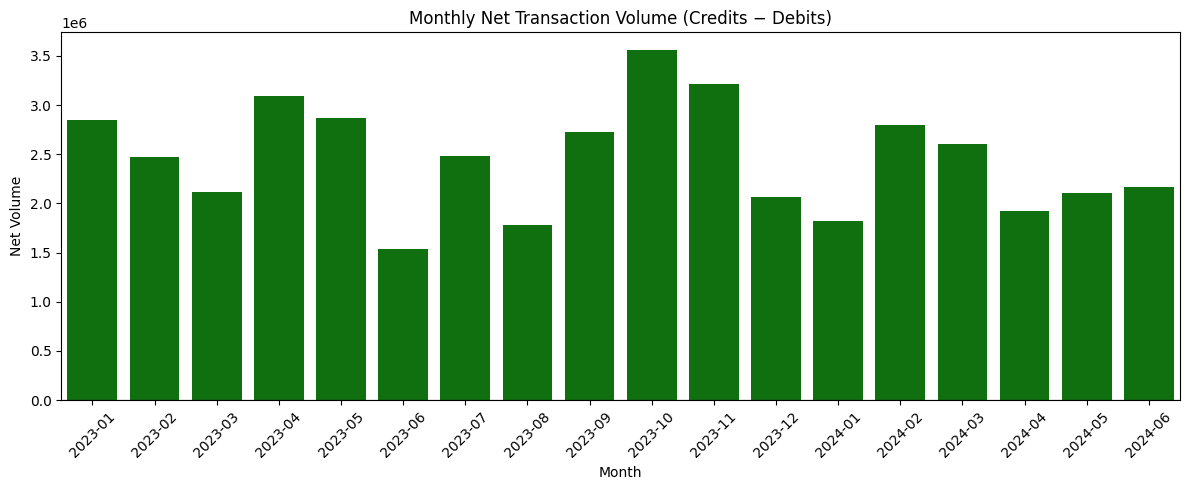

In [ ]:
# 2b. Plot trends in total credits vs. debits over time

monthly_summary['IsPositive'] = monthly_summary['NetVolume'] > 0

plt.figure(figsize=(12, 5))
sns.barplot(
    data=monthly_summary,
    x='TransactionYearMonth', y='NetVolume',
    hue='IsPositive',
    palette={True: 'green', False: 'red'},
    legend=False
)
plt.xticks(rotation=45)
plt.title('Monthly Net Transaction Volume (Credits − Debits)')
plt.xlabel('Month')
plt.ylabel('Net Volume')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1353/2984860596.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  account_net_inflow = df.groupby('AccountID').apply(



Top 10 Accounts by Net Inflow:
    AccountID     NetInflow
118  ACC61926  813650.59975
188  ACC99549  629389.22471
90   ACC48501  613988.14563
0    ACC10117  599628.73770
137  ACC72197  594850.88857
169  ACC88449  591056.73353
138  ACC73104  579351.61470
99   ACC51009  571645.42812
14   ACC16664  566389.46001
86   ACC45968  563567.92549

Bottom 10 Accounts by Net Inflow:
    AccountID     NetInflow
104  ACC52650  20125.881630
30   ACC23985  23827.889150
91   ACC49140  23972.213490
27   ACC22255  28311.013551
43   ACC28295  35629.756530
101  ACC51593  36101.521560
179  ACC94242  41142.553311
97   ACC50439  45636.953880
120  ACC62809  48493.737970
44   ACC28305  48914.494450


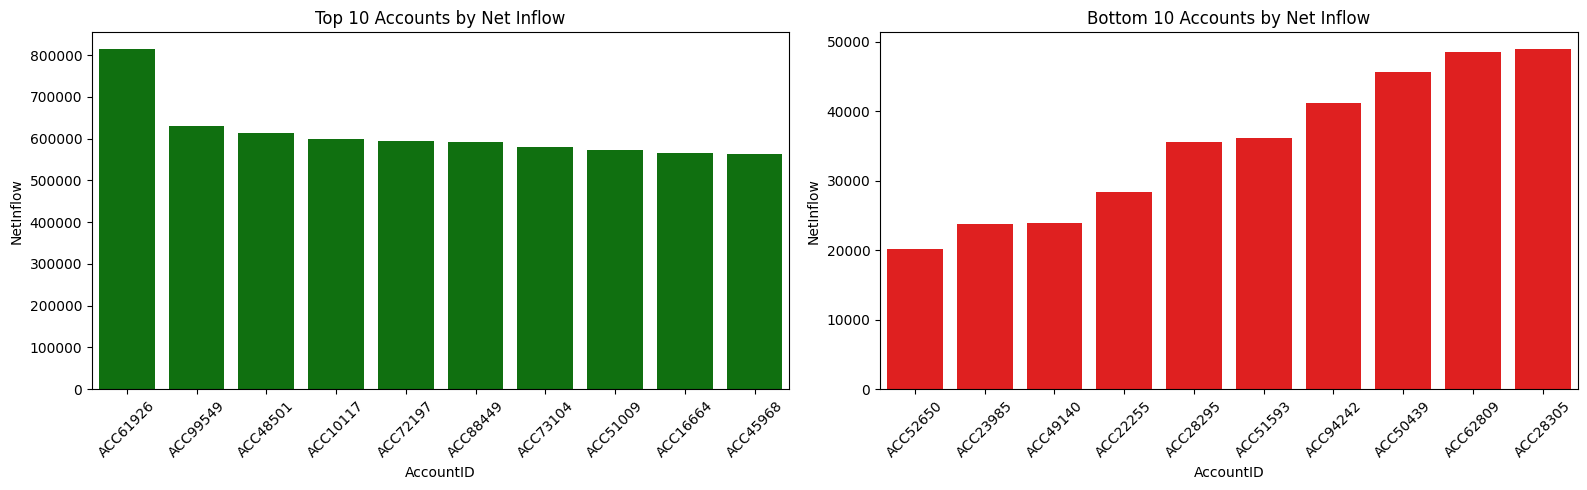

In [ ]:
# 2c. Identify top and bottom performing accounts based on net inflow

account_net_inflow = df.groupby('AccountID').apply(
    lambda x: x.loc[x['FlowType'] == 'Credit', 'AbsAmount'].sum()
             - x.loc[x['FlowType'] == 'Debit', 'AbsAmount'].sum()
).reset_index(name='NetInflow')

top_10_accounts = account_net_inflow.sort_values('NetInflow', ascending=False).head(10)
bottom_10_accounts = account_net_inflow.sort_values('NetInflow', ascending=True).head(10)

print("\nTop 10 Accounts by Net Inflow:")
print(top_10_accounts)

print("\nBottom 10 Accounts by Net Inflow:")
print(bottom_10_accounts)

# Seaborn bar plots — top and bottom side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_10_accounts, x='AccountID', y='NetInflow', ax=axes[0], color='green')
axes[0].set_title('Top 10 Accounts by Net Inflow')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=bottom_10_accounts, x='AccountID', y='NetInflow', ax=axes[1], color='red')
axes[1].set_title('Bottom 10 Accounts by Net Inflow')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



Dormant vs Active account counts:
DormantFlag
Dormant    167
Active      22
Name: count, dtype: int64


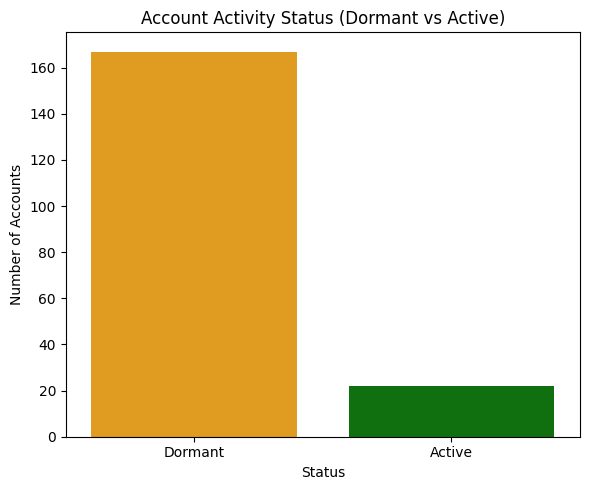


Sample dormant accounts:
  AccountID  DaysSinceLastTxn DormantFlag
0  ACC10117             128.0     Dormant
1  ACC10996             116.0     Dormant
2  ACC11062              86.0     Dormant
3  ACC11188              91.0     Dormant
4  ACC11285             129.0     Dormant
5  ACC11837             162.0     Dormant
6  ACC12182             369.0     Dormant
7  ACC12334             132.0     Dormant
8  ACC13357              90.0     Dormant
9  ACC15228             137.0     Dormant


In [ ]:
# 2d. Flag accounts as dormant/inactive if gap >= 2 months

# any two consecutive transactions is 60+ days (~2 months or more).

df_sorted = df.sort_values(['AccountID', 'TransactionDate'])
df_sorted['DaysSinceLastTxn'] = df_sorted.groupby('AccountID')['TransactionDate'].diff().dt.days

max_gap_per_account = df_sorted.groupby('AccountID')['DaysSinceLastTxn'].max().reset_index()
max_gap_per_account['DormantFlag'] = np.where(
    max_gap_per_account['DaysSinceLastTxn'] >= 60, 'Dormant', 'Active'
)

print("\nDormant vs Active account counts:")
print(max_gap_per_account['DormantFlag'].value_counts())

# Seaborn count plot
plt.figure(figsize=(6, 5))
sns.countplot(data=max_gap_per_account, x='DormantFlag', hue='DormantFlag',
              palette={'Active': 'green', 'Dormant': 'orange'}, legend=False)
plt.title('Account Activity Status (Dormant vs Active)')
plt.xlabel('Status')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

dormant_accounts = max_gap_per_account[max_gap_per_account['DormantFlag'] == 'Dormant']
print("\nSample dormant accounts:")
print(dormant_accounts.head(10))

Task 3: Customer Profile Building

In [ ]:
# 3a. Build a simple account-level summary table first

account_summary = df.groupby('AccountID').agg(
    TransactionFrequency = ('TransactionID', 'count'),
    AvgBalance = ('AccountBalance', 'mean'),
    TotalVolume = ('AbsAmount', 'sum'),
    NetInflow = ('TransactionAmount', 'sum')
).reset_index()

print("Account Summary (first 10 rows):")
print(account_summary.head(10))



Account Summary (first 10 rows):
  AccountID  TransactionFrequency    AvgBalance    TotalVolume      NetInflow
0  ACC10117                     9  94082.590727  636335.050640  599628.737700
1  ACC10996                     8  72517.761136  506746.158060  506746.158060
2  ACC11062                     4  73541.328302  247384.209240  247384.209240
3  ACC11188                     2  51359.039950  127634.925880  127634.925880
4  ACC11285                     5  79923.619870  196752.913930  169318.969530
5  ACC11837                     6  87464.766351  469907.862370  469907.862370
6  ACC12182                     3  65398.023567  102121.343150  102121.343150
7  ACC12334                     3  62897.196427   74852.576147   74852.576147
8  ACC13357                     4  79904.110278  208225.139660  208225.139660
9  ACC15228                     3  71113.049740  207947.708030  207947.708030


In [ ]:
# 3b. Group accounts by Activity Level: High / Medium / Low

#       - Low    : frequency <= 33rd percentile
#       - Medium : frequency between 33rd and 66th percentile
#       - High   : frequency >= 66th percentile
# ------------------------------------------------------------
low_cutoff = account_summary['TransactionFrequency'].quantile(0.33)
high_cutoff = account_summary['TransactionFrequency'].quantile(0.66)

print(f"Rubric: Low <= {low_cutoff:.1f} txns, Medium between, High >= {high_cutoff:.1f} txns")

def activity_level(freq):
    if freq >= high_cutoff:
        return 'High'
    elif freq <= low_cutoff:
        return 'Low'
    else:
        return 'Medium'

account_summary['ActivityLevel'] = account_summary['TransactionFrequency'].apply(activity_level)

print("\nActivity Level counts:")
print(account_summary['ActivityLevel'].value_counts())

Rubric: Low <= 3.0 txns, Medium between, High >= 5.0 txns

Activity Level counts:
ActivityLevel
Low       86
High      71
Medium    32
Name: count, dtype: int64


In [ ]:
# 3c. Segment customers by average balance and transaction volume
#     RUBRIC: split each into High/Low using the median as the cutoff

balance_median = account_summary['AvgBalance'].median()
volume_median = account_summary['TotalVolume'].median()

account_summary['BalanceSegment'] = np.where(
    account_summary['AvgBalance'] >= balance_median, 'High Balance', 'Low Balance'
)
account_summary['VolumeSegment'] = np.where(
    account_summary['TotalVolume'] >= volume_median, 'High Volume', 'Low Volume'
)

print(f"\nRubric: Balance median = {balance_median:.2f}, Volume median = {volume_median:.2f}")
print("\nSegment counts:")
print(account_summary[['BalanceSegment', 'VolumeSegment']].value_counts())



Rubric: Balance median = 72852.56, Volume median = 207100.78

Segment counts:
BalanceSegment  VolumeSegment
High Balance    High Volume      53
Low Balance     Low Volume       52
High Balance    Low Volume       42
Low Balance     High Volume      42
Name: count, dtype: int64


In [ ]:
# 3d.1 Create the three required profiles

# 1: High-net inflow accounts
# RUBRIC: NetInflow in the top 25% of all accounts
inflow_cutoff = account_summary['NetInflow'].quantile(0.75)
high_net_inflow = account_summary[account_summary['NetInflow'] >= inflow_cutoff]
print(f" High-Net Inflow Accounts (NetInflow >= {inflow_cutoff:.2f}): {len(high_net_inflow)} accounts")
print(high_net_inflow.head())


 High-Net Inflow Accounts (NetInflow >= 289387.62): 48 accounts
   AccountID  TransactionFrequency    AvgBalance   TotalVolume     NetInflow  \
0   ACC10117                     9  94082.590727  636335.05064  599628.73770   
1   ACC10996                     8  72517.761136  506746.15806  506746.15806   
5   ACC11837                     6  87464.766351  469907.86237  469907.86237   
11  ACC15671                     6  54565.019303  399388.53160  399388.53160   
14  ACC16664                    10  68276.438402  566389.46001  566389.46001   

   ActivityLevel BalanceSegment VolumeSegment  
0           High   High Balance   High Volume  
1           High    Low Balance   High Volume  
5           High   High Balance   High Volume  
11          High    Low Balance   High Volume  
14          High    Low Balance   High Volume  


In [ ]:
#  2: High-frequency, low-balance accounts
# RUBRIC: ActivityLevel = 'High' AND BalanceSegment = 'Low Balance'
high_freq_low_balance = account_summary[
    (account_summary['ActivityLevel'] == 'High') &
    (account_summary['BalanceSegment'] == 'Low Balance')
]
print(f" High-Frequency, Low-Balance Accounts: {len(high_freq_low_balance)} accounts")
print(high_freq_low_balance.head())

 High-Frequency, Low-Balance Accounts: 31 accounts
   AccountID  TransactionFrequency    AvgBalance   TotalVolume     NetInflow  \
1   ACC10996                     8  72517.761136  506746.15806  506746.15806   
11  ACC15671                     6  54565.019303  399388.53160  399388.53160   
14  ACC16664                    10  68276.438402  566389.46001  566389.46001   
18  ACC18177                     6  58248.054195  246225.81859  246225.81859   
32  ACC24508                     7  57275.485464  408087.47842  381967.95856   

   ActivityLevel BalanceSegment VolumeSegment  
1           High    Low Balance   High Volume  
11          High    Low Balance   High Volume  
14          High    Low Balance   High Volume  
18          High    Low Balance   High Volume  
32          High    Low Balance   High Volume  


In [ ]:
#  3: Accounts with negative or near-zero balances
# RUBRIC: AvgBalance <= 1000 (near-zero) OR AvgBalance < 0 (negative)
negative_near_zero = account_summary[account_summary['AvgBalance'] <= 1000]
print(f" Negative/Near-Zero Balance Accounts (AvgBalance <= 1000): {len(negative_near_zero)} accounts")
print(negative_near_zero.head())

 Negative/Near-Zero Balance Accounts (AvgBalance <= 1000): 0 accounts
Empty DataFrame
Columns: [AccountID, TransactionFrequency, AvgBalance, TotalVolume, NetInflow, ActivityLevel, BalanceSegment, VolumeSegment]
Index: []


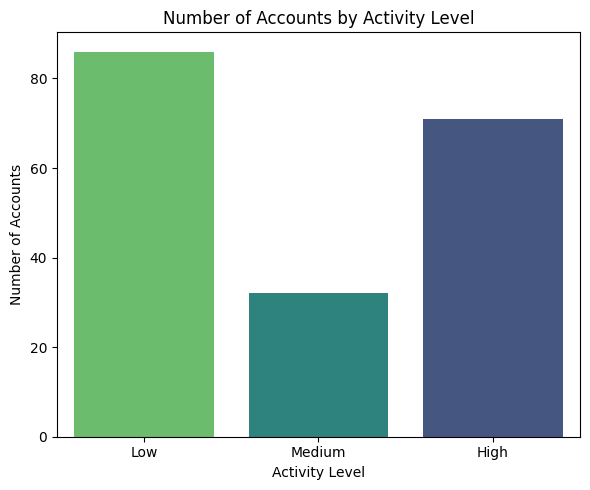

In [ ]:
# Simple visualization of Activity Levels

plt.figure(figsize=(6, 5))
sns.countplot(data=account_summary, x='ActivityLevel', order=['Low', 'Medium', 'High'],
              hue='ActivityLevel', palette='viridis', legend=False)
plt.title('Number of Accounts by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

Task 4: Financial Risk Identification.

In [ ]:
# 4a. Track accounts with frequent large withdrawals or overdrafts
#     RUBRIC:
#       - "Large withdrawal" = a Debit transaction where AbsAmount is above the 90th percentile of all debit amounts
#       - "Overdraft" = AccountBalance < 0 after the transaction
#       - "Frequent" = an account with 2 or more such events

debit_df = df[df['FlowType'] == 'Debit']
large_withdrawal_cutoff = debit_df['AbsAmount'].quantile(0.90)
print(f"Rubric: Large withdrawal = Debit amount >= {large_withdrawal_cutoff:.2f}")

df['LargeWithdrawalFlag'] = np.where(
    (df['FlowType'] == 'Debit') & (df['AbsAmount'] >= large_withdrawal_cutoff),
    1, 0
)
df['OverdraftFlag'] = np.where(df['AccountBalance'] < 0, 1, 0)

risk_events = df.groupby('AccountID').agg(
    LargeWithdrawals = ('LargeWithdrawalFlag', 'sum'),
    Overdrafts = ('OverdraftFlag', 'sum')
).reset_index()

risk_events['FrequentRiskFlag'] = np.where(
    (risk_events['LargeWithdrawals'] >= 2) | (risk_events['Overdrafts'] >= 2),
    'Yes', 'No'
)

print("\nAccounts with frequent large withdrawals/overdrafts:")
print(risk_events[risk_events['FrequentRiskFlag'] == 'Yes'])

Rubric: Large withdrawal = Debit amount >= 15652.79

Accounts with frequent large withdrawals/overdrafts:
Empty DataFrame
Columns: [AccountID, LargeWithdrawals, Overdrafts, FrequentRiskFlag]
Index: []


In [ ]:
# 4b. Calculate balance volatility (standard deviation & CV)
#     CV = Coefficient of Variation = std / mean
#     Higher CV = balance swings around a lot relative to its size
# ------------------------------------------------------------
volatility = df.groupby('AccountID')['AccountBalance'].agg(['std', 'mean']).reset_index()
volatility.columns = ['AccountID', 'BalanceStd', 'BalanceMean']
volatility['CV'] = volatility['BalanceStd'] / volatility['BalanceMean']

print("\nBalance volatility (first 10 accounts):")
print(volatility.head(10))


Balance volatility (first 10 accounts):
  AccountID    BalanceStd   BalanceMean        CV
0  ACC10117  38036.539989  94082.590727  0.404289
1  ACC10996  30036.385595  72517.761136  0.414194
2  ACC11062  33831.704345  73541.328302  0.460037
3  ACC11188   9067.866694  51359.039950  0.176558
4  ACC11285  25590.622179  79923.619870  0.320188
5  ACC11837  58878.149340  87464.766351  0.673164
6  ACC12182  30886.518182  65398.023567  0.472285
7  ACC12334   6185.019609  62897.196427  0.098335
8  ACC13357  36136.539375  79904.110278  0.452249
9  ACC15228  29519.381904  71113.049740  0.415105


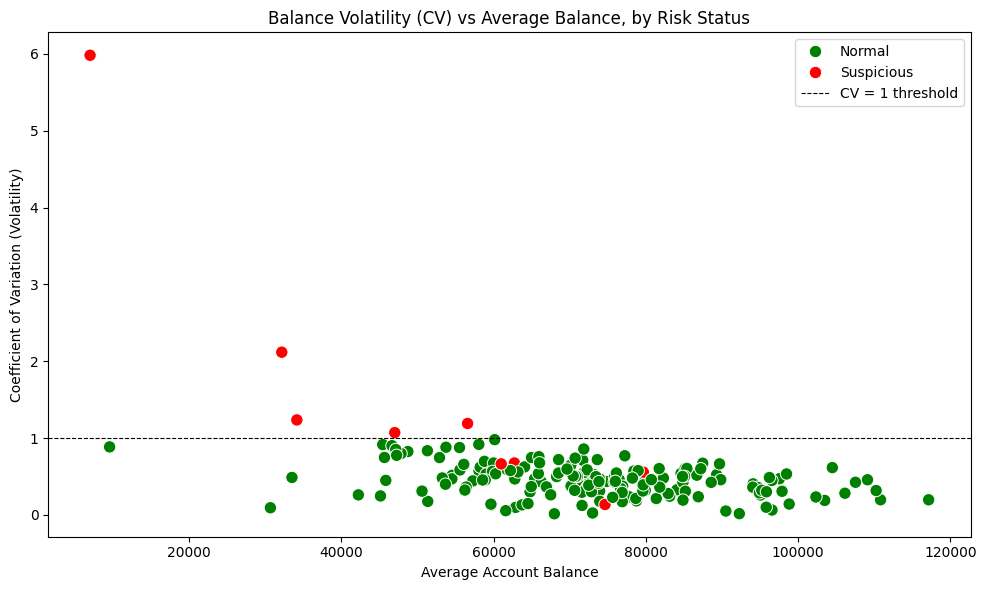

In [ ]:
# Visual: Balance volatility (CV) by account, colored by Suspicious flag
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=risk_summary, x='BalanceMean', y='CV',
    hue='SuspiciousFlag', palette={'Normal': 'green', 'Suspicious': 'red'},
    s=80
)
plt.title('Balance Volatility (CV) vs Average Balance, by Risk Status')
plt.xlabel('Average Account Balance')
plt.ylabel('Coefficient of Variation (Volatility)')
plt.axhline(1, color='black', linestyle='--', linewidth=0.8, label='CV = 1 threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4c. Detect anomalies using IQR method
#     RUBRIC: a transaction is an anomaly if TransactionAmount is outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['AnomalyFlag'] = np.where(
    (df['TransactionAmount'] < lower_bound) | (df['TransactionAmount'] > upper_bound),
    'Anomaly', 'Normal'
)

print(f"\nRubric: Normal range = [{lower_bound:.2f}, {upper_bound:.2f}]")
print("\nAnomaly counts:")
print(df['AnomalyFlag'].value_counts())



Rubric: Normal range = [-24988.92, 134560.63]

Anomaly counts:
AnomalyFlag
Normal     795
Anomaly      5
Name: count, dtype: int64


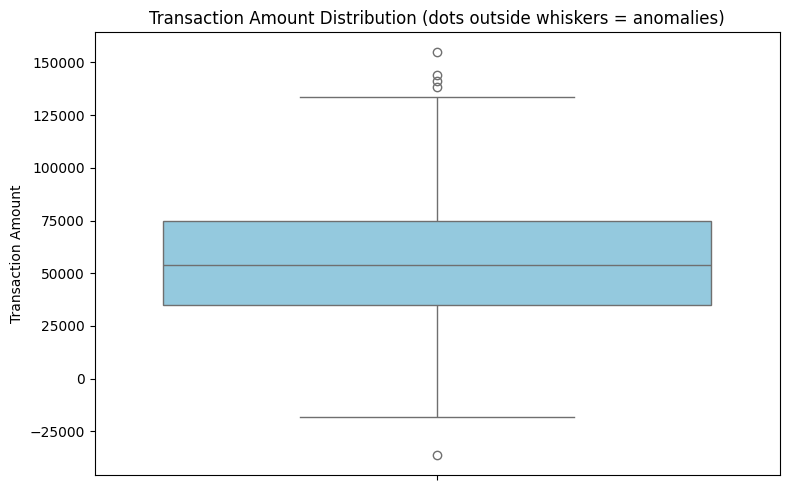

In [ ]:
# Visual: Boxplot showing transaction amount spread and anomalies
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='TransactionAmount', color='skyblue')
plt.title('Transaction Amount Distribution (dots outside whiskers = anomalies)')
plt.ylabel('Transaction Amount')
plt.tight_layout()
plt.show()

In [ ]:
# 4d. Highlight customers with irregular/suspicious behavior
#     RUBRIC: a customer is "Suspicious" if they have:
#       - FrequentRiskFlag = Yes, OR
#       - CV > 1 (very volatile balance), OR
#       - at least 1 anomalous transaction

anomaly_counts = df[df['AnomalyFlag'] == 'Anomaly'].groupby('AccountID').size().reset_index(name='AnomalyCount')

# Merge everything into one risk table
risk_summary = risk_events.merge(volatility, on='AccountID', how='left')
risk_summary = risk_summary.merge(anomaly_counts, on='AccountID', how='left')
risk_summary['AnomalyCount'] = risk_summary['AnomalyCount'].fillna(0)

risk_summary['SuspiciousFlag'] = np.where(
    (risk_summary['FrequentRiskFlag'] == 'Yes') |
    (risk_summary['CV'] > 1) |
    (risk_summary['AnomalyCount'] >= 1),
    'Suspicious', 'Normal'
)

print("\nSuspicious vs Normal account counts:")
print(risk_summary['SuspiciousFlag'].value_counts())

print("\nSuspicious accounts (sample):")
print(risk_summary[risk_summary['SuspiciousFlag'] == 'Suspicious'].head(10))


Suspicious vs Normal account counts:
SuspiciousFlag
Normal        179
Suspicious     10
Name: count, dtype: int64

Suspicious accounts (sample):
    AccountID  LargeWithdrawals  Overdrafts FrequentRiskFlag    BalanceStd  \
20   ACC19178                 0           0               No  44358.672969   
29   ACC23736                 0           0               No  19566.250141   
38   ACC26940                 0           1               No  41981.613421   
66   ACC35419                 1           0               No  42423.135120   
116  ACC60432                 0           1               No  50384.539932   
133  ACC70741                 0           1               No  67364.539557   
145  ACC77533                 0           0               No  10149.052992   
152  ACC78589                 0           1               No  42257.915468   
175  ACC92104                 0           0               No  40526.137323   
185  ACC97411                 0           1               No  68179.288932

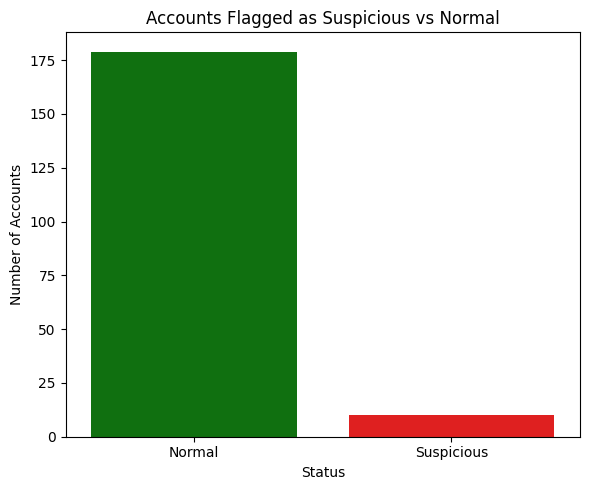

In [ ]:
# Visual: Suspicious vs Normal accounts (count)
plt.figure(figsize=(6, 5))
sns.countplot(data=risk_summary, x='SuspiciousFlag', hue='SuspiciousFlag',
              palette={'Normal': 'green', 'Suspicious': 'red'}, legend=False)
plt.title('Accounts Flagged as Suspicious vs Normal')
plt.xlabel('Status')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()


Task 5: Visualisation (Extensive EDA)

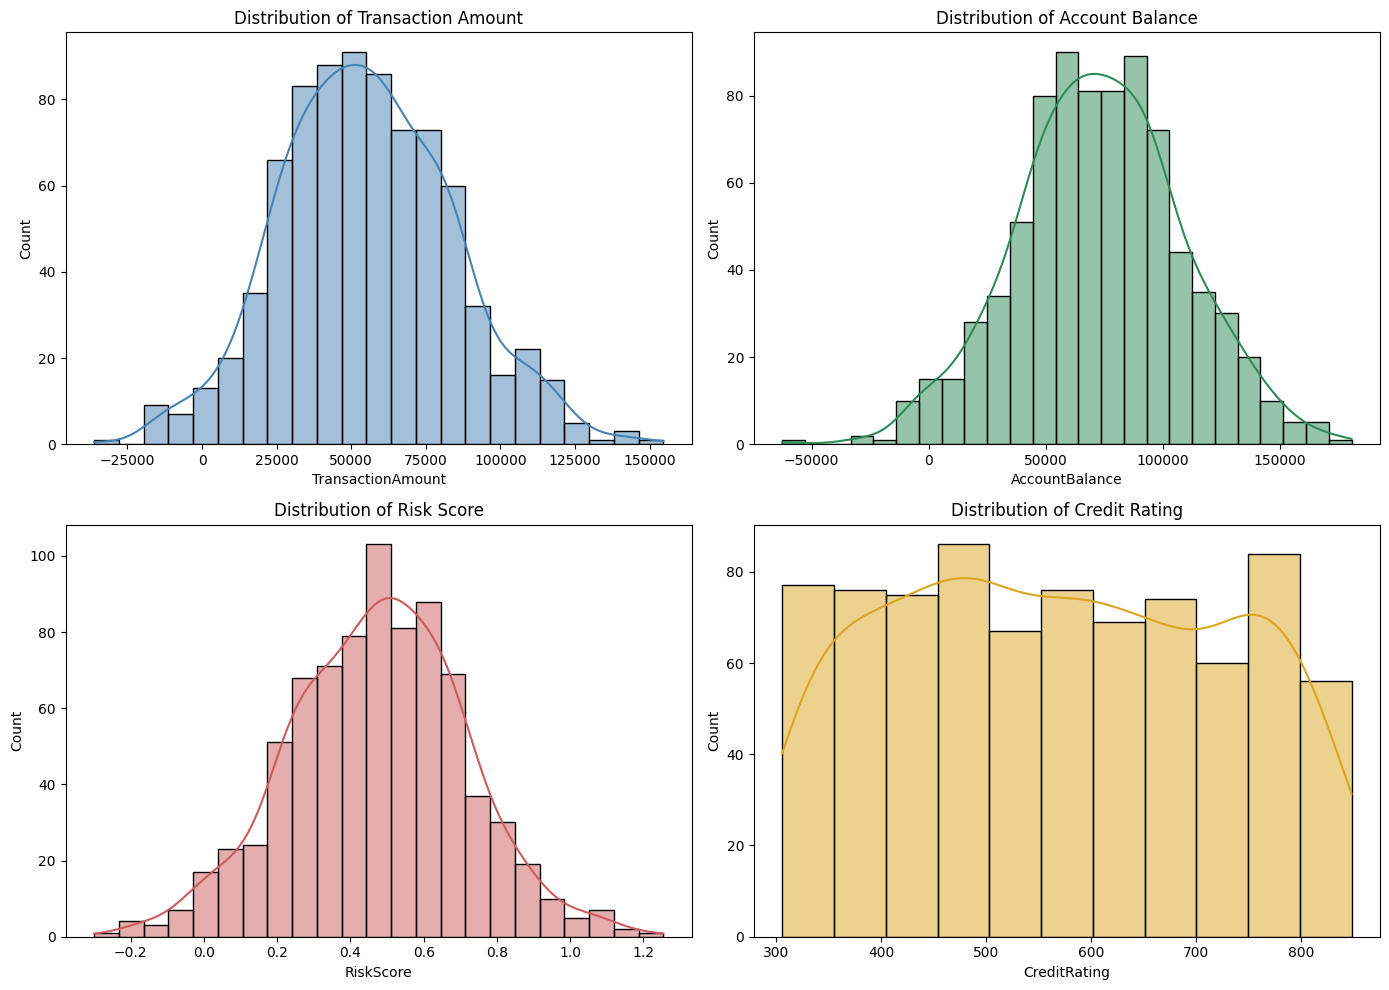

In [ ]:
# 5a. Distribution of key numeric fields
# histograms show the overall shape of each numeric field (are balances normally distributed? skewed?).

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['TransactionAmount'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Transaction Amount')

sns.histplot(df['AccountBalance'], kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Distribution of Account Balance')

sns.histplot(df['RiskScore'], kde=True, ax=axes[1,0], color='indianred')
axes[1,0].set_title('Distribution of Risk Score')

sns.histplot(df['CreditRating'], kde=True, ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Distribution of Credit Rating')

plt.tight_layout()
plt.show()


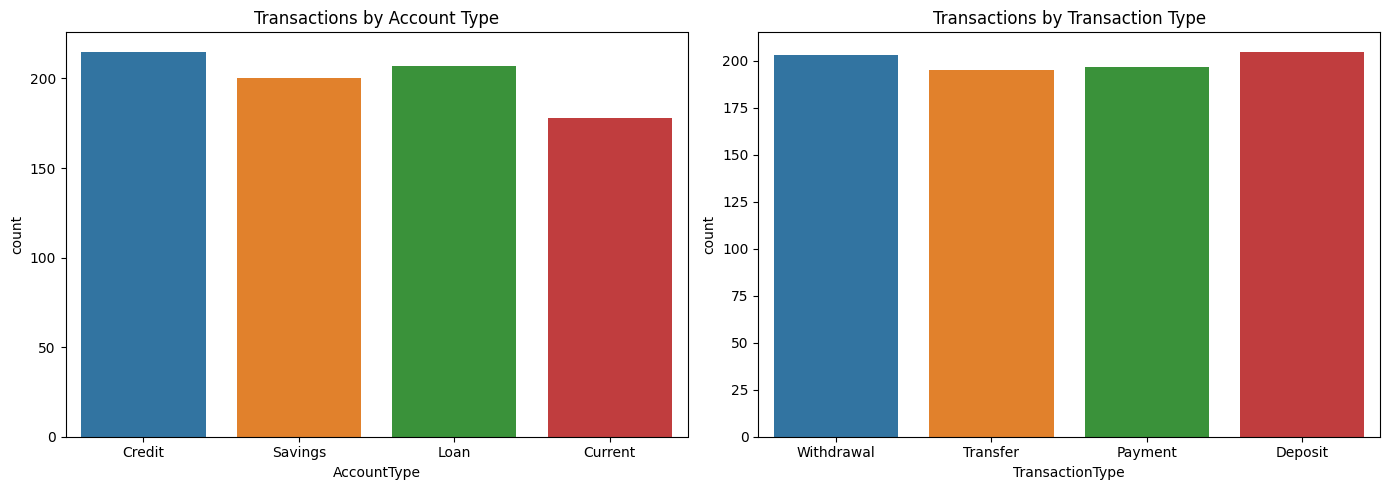

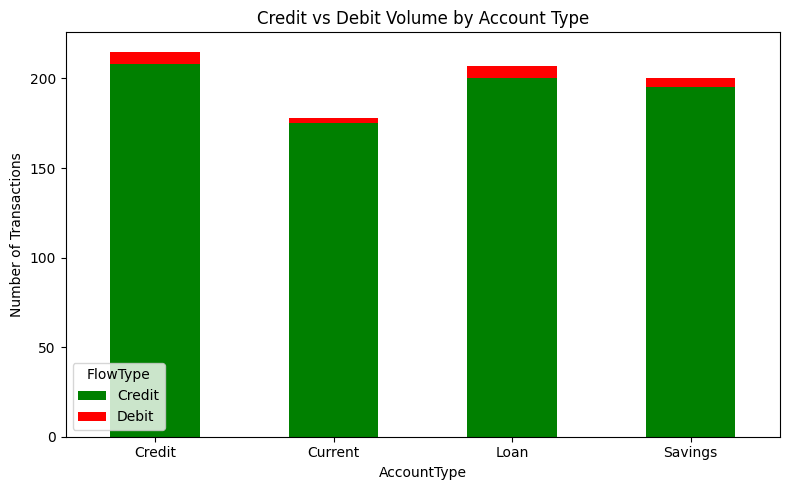

In [ ]:
# 5b. Account types and transaction types - how customers interact
#  bar/stacked charts show how customers use different account types, and whether certain account types lean more credit-heavy or debit-heavy.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='AccountType', hue='AccountType', ax=axes[0], legend=False)
axes[0].set_title('Transactions by Account Type')

sns.countplot(data=df, x='TransactionType', hue='TransactionType', ax=axes[1], legend=False)
axes[1].set_title('Transactions by Transaction Type')

plt.tight_layout()
plt.show()

# Cross-tab: Account Type vs Flow Type (Credit/Debit) - stacked view
crosstab = pd.crosstab(df['AccountType'], df['FlowType'])
crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), color=['green', 'red'])
plt.title('Credit vs Debit Volume by Account Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


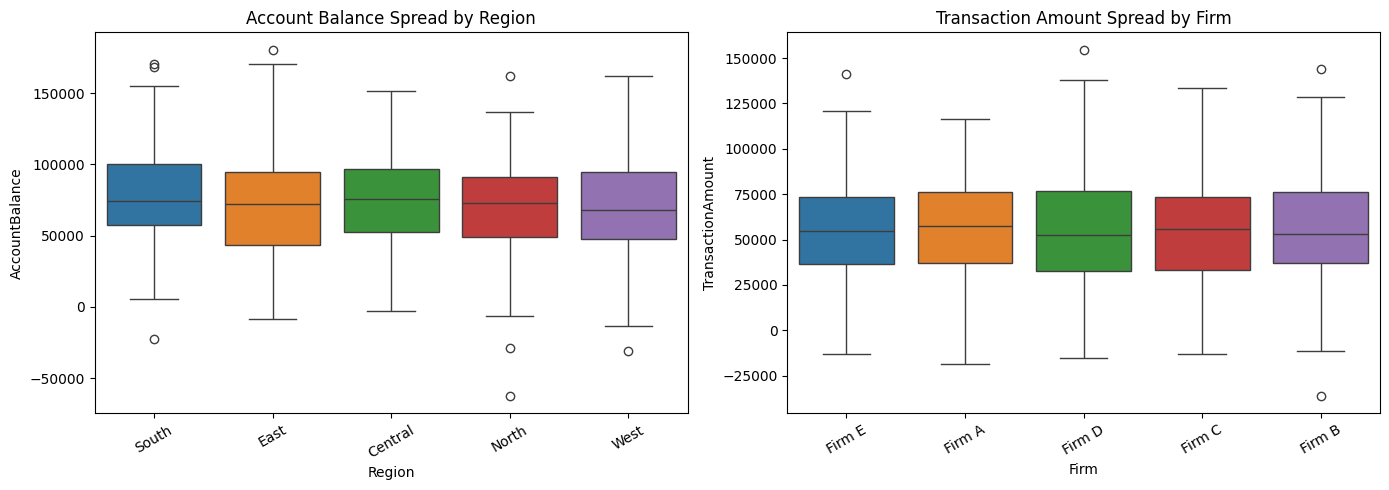

In [ ]:
# 5c. Regional and firm-level patterns
# boxplots compare balance and transaction spread across regions/firms and is useful to spot if one region is riskier or wealthier.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Region', y='AccountBalance', hue='Region', ax=axes[0], legend=False)
axes[0].set_title('Account Balance Spread by Region')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Firm', y='TransactionAmount', hue='Firm', ax=axes[1], legend=False)
axes[1].set_title('Transaction Amount Spread by Firm')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


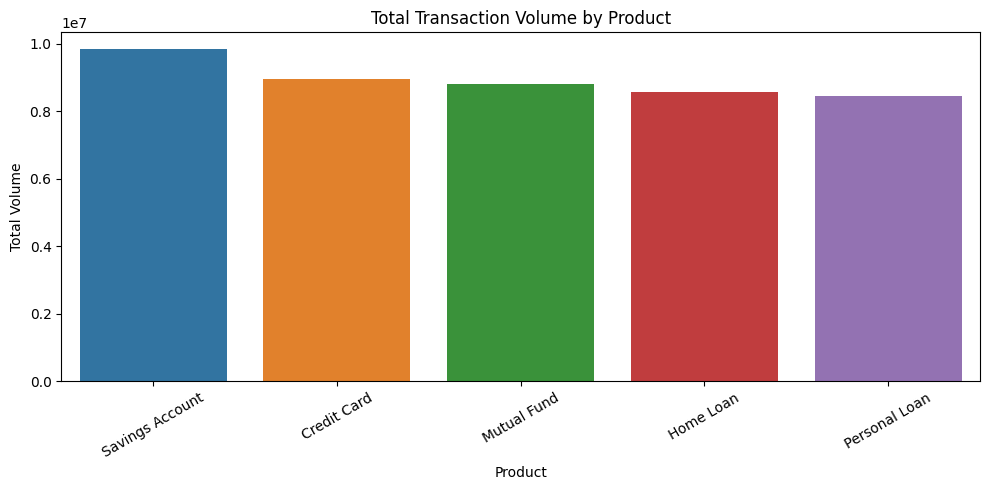

In [ ]:
# 5d. Product-wise transaction volume
# shows which financial products (Credit Card, Mutual Fund, Home Loan, etc.) drive the most transaction volume.

product_volume = df.groupby('Product')['AbsAmount'].sum().reset_index().sort_values('AbsAmount', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=product_volume, x='Product', y='AbsAmount', hue='Product', legend=False)
plt.title('Total Transaction Volume by Product')
plt.xticks(rotation=30)
plt.ylabel('Total Volume')
plt.tight_layout()
plt.show()


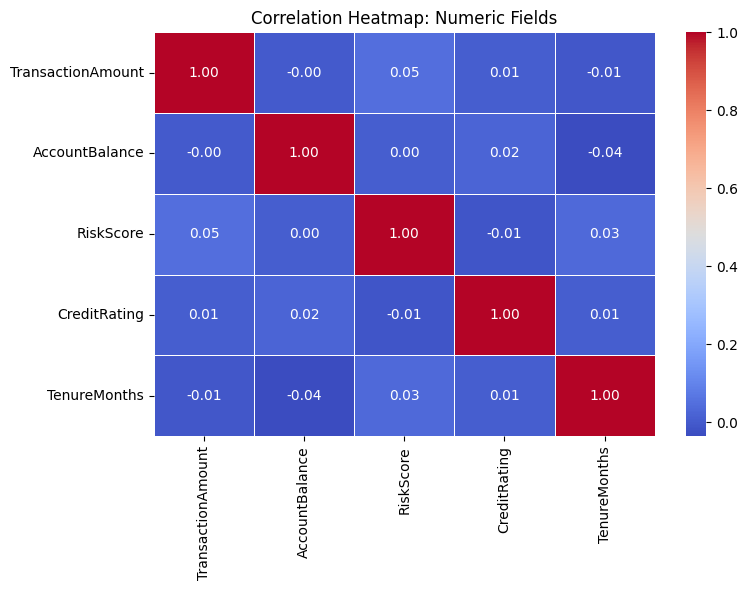

In [ ]:
# 5e. Correlation heatmap - relationships between numeric fields
# it directly answers "what correlates with lower balances / risk," which is one of the leadership questions in your brief.


numeric_cols = ['TransactionAmount', 'AccountBalance', 'RiskScore', 'CreditRating', 'TenureMonths']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Numeric Fields')
plt.tight_layout()
plt.show()


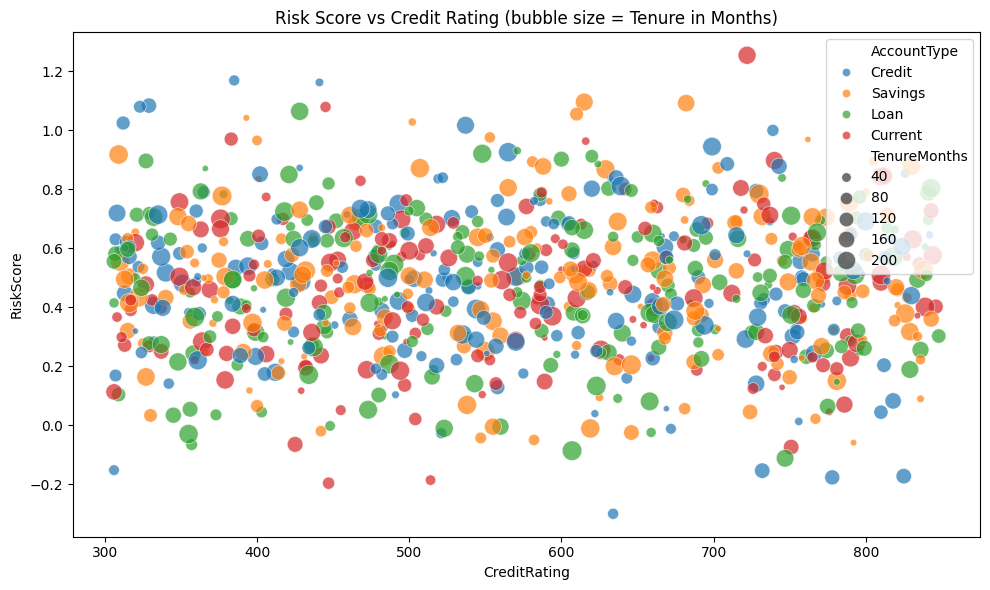

In [ ]:
# 5f. Risk Score vs Credit Rating vs Tenure - deeper relationship view
#  a bubble chart combining three variables at once (risk, credit rating, tenure) is visually impressive.

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='CreditRating', y='RiskScore',
    hue='AccountType', size='TenureMonths', sizes=(20, 200), alpha=0.7
)
plt.title('Risk Score vs Credit Rating (bubble size = Tenure in Months)')
plt.tight_layout()
plt.show()

Task 6: Hypothesis Testing

In [ ]:
# 6a. Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts .

# Hypotheses:
# H0 (Null): No difference in average balance between High Volume and Low Volume accounts
# H1 (Alt):  High Volume accounts have a HIGHER average balance than Low Volume accounts
# Test used: Independent two-sample t-test (one-tailed)
# Significance level: alpha = 0.05

high_volume_balances = account_summary[account_summary['VolumeSegment'] == 'High Volume']['AvgBalance']
low_volume_balances = account_summary[account_summary['VolumeSegment'] == 'Low Volume']['AvgBalance']

print("High Volume accounts - mean balance:", high_volume_balances.mean())
print("Low Volume accounts  - mean balance:", low_volume_balances.mean())

# Running the t-test (Welch's t-test, doesn't assume equal variance - safer default)
t_stat, p_value_two_tailed = stats.ttest_ind(
    high_volume_balances, low_volume_balances, equal_var=False
)
# Converting to one-tailed p-value since our H1 has a direction ("higher than")
p_value_one_tailed = p_value_two_tailed / 2 if t_stat > 0 else 1 - (p_value_two_tailed / 2)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.4f}")

alpha = 0.05
if p_value_one_tailed < alpha:
    print(f"\nResult: p < {alpha} -> Reject H0. High-volume accounts DO have significantly higher average balances.")
else:
    print(f"\nResult: p >= {alpha} -> Fail to reject H0. No significant evidence that high-volume accounts have higher balances.")

High Volume accounts - mean balance: 73725.66702694514
Low Volume accounts  - mean balance: 70176.84868076064

T-statistic: 1.3103
One-tailed p-value: 0.0960

Result: p >= 0.05 -> Fail to reject H0. No significant evidence that high-volume accounts have higher balances.


In [ ]:
# 6b. Second test based on segmentation: Does Activity Level (High/Medium/Low) affect average balance?

# Hypotheses:
#   H0: Average balance is the same across High, Medium, Low activity groups
#   H1: At least one activity group has a different average balance

# Test used: One-way ANOVA (comparing more than 2 groups)
# Significance level: alpha = 0.05


high_activity = account_summary[account_summary['ActivityLevel'] == 'High']['AvgBalance']
medium_activity = account_summary[account_summary['ActivityLevel'] == 'Medium']['AvgBalance']
low_activity = account_summary[account_summary['ActivityLevel'] == 'Low']['AvgBalance']

f_stat, p_value_anova = stats.f_oneway(high_activity, medium_activity, low_activity)

print(f"\nANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_value_anova:.4f}")

if p_value_anova < alpha:
    print(f"Result: p < {alpha} -> Reject H0. Average balance differs significantly across activity levels.")
else:
    print(f"Result: p >= {alpha} -> Fail to reject H0. No significant difference in balance across activity levels.")




ANOVA F-statistic: 1.8014
ANOVA p-value: 0.1679
Result: p >= 0.05 -> Fail to reject H0. No significant difference in balance across activity levels.


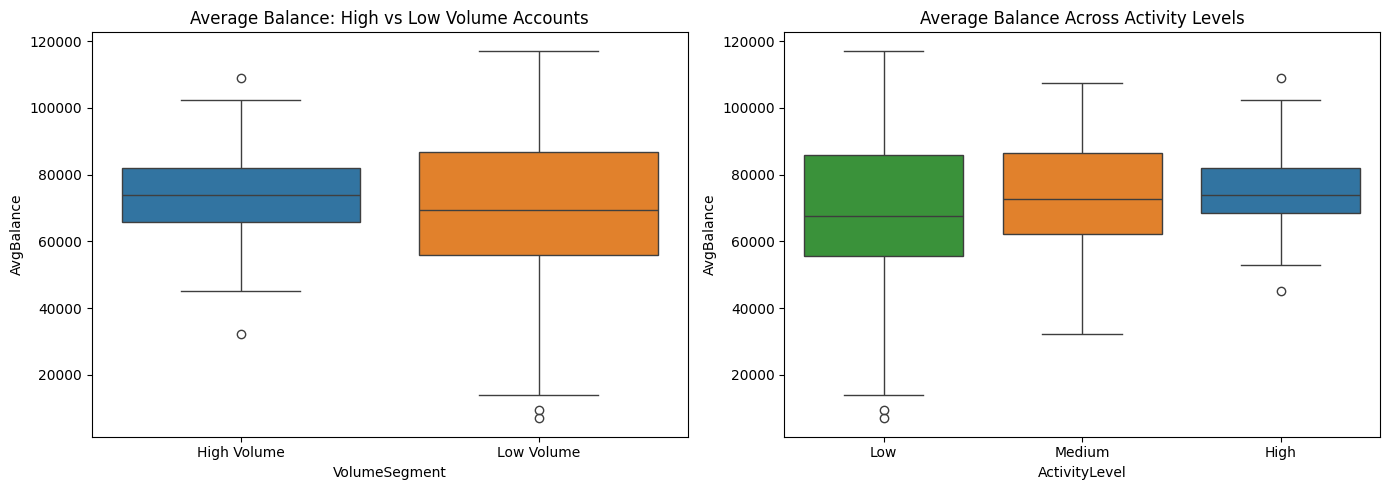

In [ ]:
# 6c. Visualizing both comparisons

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=account_summary, x='VolumeSegment', y='AvgBalance',
            hue='VolumeSegment', ax=axes[0], legend=False)
axes[0].set_title('Average Balance: High vs Low Volume Accounts')

sns.boxplot(data=account_summary, x='ActivityLevel', y='AvgBalance',
            order=['Low', 'Medium', 'High'], hue='ActivityLevel', ax=axes[1], legend=False)
axes[1].set_title('Average Balance Across Activity Levels')

plt.tight_layout()
plt.show()

TASK 7: Project Summary: Customer Financial Behavior & Risk Analysis

800 transactions across 189 unique accounts, cleaned with 0 missing values and 0 duplicates, spanning Jan 2023 – Jun 2024.

Key Insights:

1. Account & Transaction Behavior

• 4 Account types (Credit, Savings, Loan, Current) and 4 transaction types (Withdrawal, Transfer, Payment, Deposit) & no data inconsistencies were found after cleaning.

• Credits (inflows) vastly outweigh Debits (outflows) by transaction value: 2023 saw 30.9M in credits vs. only 206K in debits .2024 (partial year) saw 13.4M credits vs. 15K debits.

• Credit volume peaked in October 2023 (3.56M) & every month shows a strongly positive net transaction volume.

2. Account Performance

• Top-performing account by net inflow: ACC61926 (813,650) &
Lowest-performing: ACC52650 (20,126)

• 167 of 189 accounts (88%) were flagged as dormant (60+ day gap between consecutive transactions) & only 22 accounts stayed continuously active.

• Net transaction volume was positive in every single month analyzed &  no month showed outflows exceeding inflows.

3. Customer Segmentation

• Activity levels (based on transaction frequency terciles): 86 Low, 32 Medium, 71 High activity accounts.

• 48 accounts (top 25%) qualify as High-Net-Inflow (NetInflow ≥ 289,388)

• 31 accounts are High-Frequency/Low-Balance — active customers holding below-median balances.

• 0 accounts had negative or near-zero balances (≤ 1,000),  no customers are operating at critical balance levels

4. Financial Risk

• 0 accounts showed "frequent" large withdrawals or overdrafts (2+ occurrences) & no account crossed the 90th-percentile large-withdrawal cutoff (15,653) more than once, and none had repeat overdrafts.

• 10 of 189 accounts (5.3%) flagged as Suspicious, driven mainly by high balance volatility (CV > 1) or at least one anomalous transaction — e.g., ACC26940 had a coefficient of variation of 5.98, meaning its balance swings nearly 6x its average.

• IQR method flagged 5 of 800 transactions (0.6%) as statistical anomalies (outside -24,989 to 134,561).

5. Statistical Findings

• Volume vs. Balance (t-test): Fail to reject H0 (p = 0.096) — no statistically significant evidence that high-volume accounts hold higher average balances than low-volume ones, despite a modest observed difference (₹73,726 vs ₹70,177).

• Activity Level vs. Balance (ANOVA): Fail to reject H0 (p = 0.168) — balance does not differ significantly across Low/Medium/High activity groups


Recommendations:

• Prioritize the 167 dormant accounts (88%) for a re-engagement campaign .

•Monitor the 10 Suspicious-flagged accounts, especially the highest-CV ones (e.g., ACC26940 at CV ≈ 5.98), for manual review even though none show repeat overdrafts yet.


• Reassure leadership on immediate risk: 0 accounts are near-zero/negative balance, and 0 accounts show frequent large withdrawals — the customer base looks financially stable overall, aside from the volatility-driven suspicious accounts.


• Don't force a "yes" on the hypothesis tests — be upfront that transaction volume and activity level do not significantly predict account balance in this dataset (p = 0.096, p = 0.168). Recommend leadership look at other drivers (e.g., tenure, credit rating, product type) instead


• Track the 31 high-frequency/low-balance accounts separately from the 10 flagged-Suspicious accounts — they're not statistically anomalous but represent a behaviorally distinct, at-risk-adjacent segment worth proactive outreach


• Investigate why dormancy is so widespread (88%) — with a small sample of transactions per account, this may reflect data sparsity rather than true customer disengagement.